# Model Training

### 1 - Library Import

In [24]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
    
from src.data_processing import load_train_data
from src.data_processing import load_test_data
from src.model_evaluation import evaluate
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### 2 - Data Prepping

In [2]:
df_train = load_train_data("../CMAPSSData/train_FD001.txt")

df_test = load_test_data("../CMAPSSData/test_FD001.txt", "../CMAPSSData/RUL_FD001.txt")

variance_table = df_train[df_train.columns[5:26]]
variance_table = variance_table.var()
variance_table = variance_table.to_frame(name='Variance')
variance_table = variance_table.round(5)
high_variance_features = variance_table[variance_table['Variance'] != 0].index.tolist()

X_train = df_train[high_variance_features]
y_train = df_train['RUL']

X_test = df_test[high_variance_features]
y_test = df_test['RUL']

### 3 - Ridge

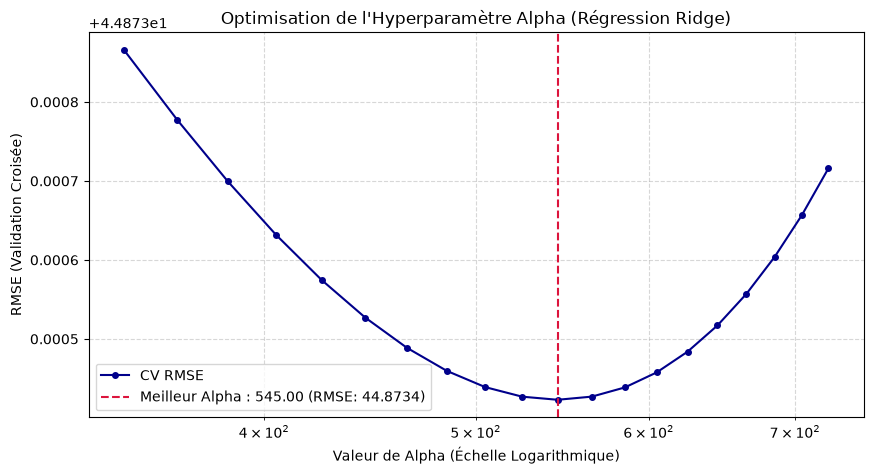

In [32]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(random_state=42))
])

groups = df_train['unit']
gkf = GroupKFold(n_splits=5)

# param_grid={'ridge__alpha': [i for i in range(0, 10000, 100)]}
# param_grid={'ridge__alpha': [i for i in range(400, 600, 10)]}
# param_grid={'ridge__alpha': [i for i in range(530, 550)]}
param_grid = {'ridge__alpha': [i for i in range(345, 745, 20)]}

ridge_cv = GridSearchCV(
    pipeline,
    param_grid=param_grid,  
    cv=gkf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1   
)
ridge_cv.fit(X_train, y_train, groups=groups)

alphas_testes = np.array(ridge_cv.cv_results_['param_ridge__alpha'], dtype=float)
cv_rmse = -ridge_cv.cv_results_['mean_test_score'] 
best_alpha = ridge_cv.best_params_['ridge__alpha']
best_score = -ridge_cv.best_score_

plt.figure(figsize=(10, 5))
plt.plot(alphas_testes, cv_rmse, marker='o', linestyle='-', color='darkblue', markersize=4, label='CV RMSE')
plt.axvline(x=best_alpha, color='crimson', linestyle='--', linewidth=1.5, 
            label=f'Meilleur Alpha : {best_alpha:.2f} (RMSE: {best_score:.4f})')
plt.xscale('log')
plt.xlabel('Valeur de Alpha (Échelle Logarithmique)')
plt.ylabel('RMSE (Validation Croisée)')
plt.title('Optimisation de l\'Hyperparamètre Alpha (Régression Ridge)')
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()

In [ ]:
y_pred_all = ridge_cv.best_estimator_.predict(X_test)
evaluate(y_test, y_pred_all, label="All test rows")

# Official metric — last cycle per engine only
last_idx = df_test.groupby("unit")["cycle"].idxmax()
X_test_last = df_test.loc[last_idx, high_variance_features]
y_test_last = df_test.loc[last_idx, "RUL"]

y_pred_last = ridge_cv.best_estimator_.predict(X_test_last)
evaluate(y_test_last, y_pred_last, label="Last cycle per engine (official)")


  All test rows
  RMSE  : 62.3435
  Score : 362609622.8523

  Last cycle per engine (official)
  RMSE  : 63.8687
  Score : 13570592.5172


(np.float64(63.868668549485804), np.float64(13570592.517197836))

In [5]:
feature_names = high_variance_features
coefs = ridge_cv.best_estimator_.named_steps['ridge'].coef_

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)
print(coef_df)

   feature  coefficient
6      s11    -9.952669
7      s12     7.847244
5       s9    -7.713305
2       s4    -6.881459
3       s7     6.099981
9      s14    -5.220697
10     s15    -4.498995
13     s21     4.450653
12     s20     3.603601
0       s2    -3.415728
11     s17    -2.870814
1       s3    -2.700125
4       s8    -0.957280
8      s13    -0.882173
